# 🗳️ Social Listener — Pipeline Overview Notebook

**Project**: UOG AIS Social Listener — 2020 US Election Twitter Sentiment Analysis  
**Coverage Window**: 2020-10-15 → 2020-11-08  

**Hypotheses**:
- **H1 (ITSA)**: Do political events cause measurable immediate shocks and slope changes in Twitter sentiment?
- **H2 (Spatial OLS)**: Does state-level online sentiment margin predict the 2020 electoral vote margin?

---
This notebook loads the **actual processed output** from Phases 1–5 and produces:
| Section | Content |
|---|---|
| Phase 1 | Dataset overview, daily volume by candidate stream |
| Phase 2 | Preprocessing funnel, activity audit, language-region cross-tab |
| Phase 3 | Sentiment distributions, VADER scoring, sarcasm risk |
| Phase 4 | Temporal sentiment time series, event window shock plots, spatial matrix |
| Phase 5 | H1 ITSA regression results, H2 OLS scatter, stratified comparison, diagnostics |


In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm

# Smart ROOT path resolution: auto-detect project root whether notebook kernel
# is started from project root or from inside notebooks/ directory in Jupyter/VS Code.
ROOT = Path(".").resolve()
if not (ROOT / "data").exists():
    ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

# Windows asyncio fix for zmq/tornado compatibility
import asyncio, platform
if platform.system() == "Windows":
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())


sns.set_theme(style="whitegrid", context="notebook", font_scale=1.15)
plt.rcParams.update({
    "figure.facecolor": "#F8F9FC",
    "axes.facecolor":   "#F8F9FC",
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

TRUMP_COLOR   = "#C0392B"
BIDEN_COLOR   = "#2980B9"
NEUTRAL_COLOR = "#7F8C8D"
POS_COLOR     = "#27AE60"
NEG_COLOR     = "#E74C3C"
BG_COLOR      = "#F39C12"

GRAPH_OUT = ROOT / "output" / "graphs" / "overview_notebook"
GRAPH_OUT.mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")
print("✅ Setup complete — graphs →", GRAPH_OUT)


✅ Setup complete — graphs → D:\GW_UNIVERSITY\AIS\Social_Listener\Env\Social_Listener_V1\UOG_AIS_SOCIAL_LISTENER\output\graphs\overview_notebook


---
## 📥 Phase 1 — Data Ingestion

Two candidate **hashtag streams** collected from Kaggle's 2020 US election tweets:
- **#donaldtrump** — Trump-hashtag tweets
- **#joebiden** — Biden-hashtag tweets

**Important**: `candidate` column = hashtag stream membership, **not political stance**.  
A Trump critic can tweet `#donaldtrump`. Stance is determined later by sentiment.

Window: **2020-10-15 → 2020-11-08** (Election Day).


In [2]:
with open(ROOT / "output" / "results" / "phase1" / "v2" / "ingestion_manifest_v2.json") as f:
    p1 = json.load(f)

trump_n = p1["streams"]["twitter_donald_trump_v2"]["record_count"]
biden_n = p1["streams"]["twitter_joe_biden_v2"]["record_count"]
overlap  = p1["cross_stream_overlap"]["overlapping_tweet_ids"]
print(f"Trump stream : {trump_n:>10,} records")
print(f"Biden stream : {biden_n:>10,} records")
print(f"Combined     : {trump_n+biden_n:>10,} records")
print(f"Cross-stream overlap: {overlap:,} tweet IDs (same tweet in both streams — lineage only)")


Trump stream :    970,765 records
Biden stream :    776,777 records
Combined     :  1,747,542 records
Cross-stream overlap: 221,686 tweet IDs (same tweet in both streams — lineage only)


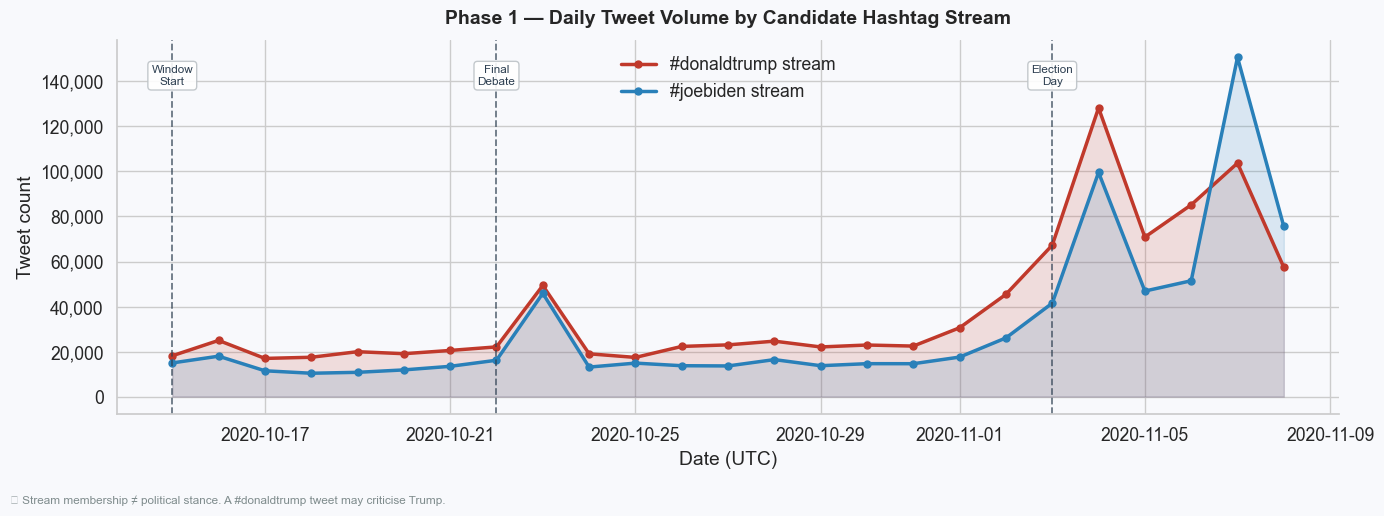

Trump peak: 2020-11-04 — 128,235 tweets
Biden peak: 2020-11-07 — 150,700 tweets


In [3]:
trump_p1 = pd.read_parquet(ROOT / "data" / "02_interim" / "phase1_v2" / "twitter_donald_trump_v2.parquet")
biden_p1 = pd.read_parquet(ROOT / "data" / "02_interim" / "phase1_v2" / "twitter_joe_biden_v2.parquet")

for df in (trump_p1, biden_p1):
    df["_day"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce").dt.floor("D")

trump_daily = trump_p1.dropna(subset=["_day"]).groupby("_day").size().rename("Trump")
biden_daily = biden_p1.dropna(subset=["_day"]).groupby("_day").size().rename("Biden")
daily_vol   = pd.concat([trump_daily, biden_daily], axis=1).fillna(0).astype(int)

key_events = [
    (pd.Timestamp("2020-10-15", tz="UTC"), "Window\nStart"),
    (pd.Timestamp("2020-10-22", tz="UTC"), "Final\nDebate"),
    (pd.Timestamp("2020-11-03", tz="UTC"), "Election\nDay"),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_vol.index, daily_vol["Trump"], alpha=0.15, color=TRUMP_COLOR)
ax.fill_between(daily_vol.index, daily_vol["Biden"], alpha=0.15, color=BIDEN_COLOR)
ax.plot(daily_vol.index, daily_vol["Trump"], color=TRUMP_COLOR, lw=2.5, marker="o", ms=5, label="#donaldtrump stream")
ax.plot(daily_vol.index, daily_vol["Biden"], color=BIDEN_COLOR, lw=2.5, marker="o", ms=5, label="#joebiden stream")

ymax = max(daily_vol.max())
for dt, lbl in key_events:
    ax.axvline(dt, color="#2C3E50", lw=1.3, ls="--", alpha=0.7)
    ax.text(dt, ymax * 0.92, lbl, ha="center", fontsize=8.5, color="#2C3E50",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#BDC3C7", alpha=0.9))

ax.set_title("Phase 1 — Daily Tweet Volume by Candidate Hashtag Stream", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Tweet count")
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(frameon=False)
fig.text(0.01, -0.03,
    "⚠ Stream membership ≠ political stance. A #donaldtrump tweet may criticise Trump.",
    fontsize=8.5, color="#7F8C8D")
plt.tight_layout()
plt.savefig(GRAPH_OUT / "phase1_daily_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Trump peak: {daily_vol['Trump'].idxmax().date()} — {daily_vol['Trump'].max():,} tweets")
print(f"Biden peak: {daily_vol['Biden'].idxmax().date()} — {daily_vol['Biden'].max():,} tweets")


---
## 🧹 Phase 2 — Preprocessing Pipeline

Three sequential filters applied to the combined raw dataset:

| Stage | Filter | Rationale |
|---|---|---|
| 1 | **Activity filter** — remove users > P99.5 tweets/active day | Suppress bot/spam amplification |
| 2 | **Text cleaning** — remove tweets empty after URL/HTML stripping | Eliminate content-free records |
| 3 | **Dedup on cleaned text** — remove exact duplicates after cleaning | Collapse URL-variant duplicates |

> **Key fix**: Deduplication runs *after* cleaning — so `"Vote Biden https://t.co/abc"` and  
> `"Vote Biden https://t.co/xyz"` correctly collapse into one record (both clean to `"Vote Biden"`).

### Package D — Language-Region Cross-Analysis
Because no `detected_language` column exists in the raw data, a **heuristic regex pattern matcher**  
identifies Spanish-language tweets using Spanish function words and accented characters.  
Spanish-speaking US residents (e.g. TX, FL, CA, AZ) are **retained** — not filtered.


In [4]:
with open(ROOT / "output" / "results" / "phase2" / "v2" / "preprocessing_manifest_v2.json") as f:
    p2 = json.load(f)

initial  = p2["initial_record_count"]
rm_act   = p2["tweets_removed_activity_filter"]
rm_clean = p2["tweets_removed_text_cleaning"]
rm_dedup = p2["tweets_removed_exact_duplicate_filter"]
final    = p2["final_cleaned_record_count"]
thresh   = p2["selected_activity_threshold"]

print(f"Initial records    : {initial:>10,}")
print(f"Removed (activity) : {rm_act:>10,}  ({rm_act/initial*100:.2f}%)")
print(f"Removed (cleaning) : {rm_clean:>10,}  ({rm_clean/initial*100:.2f}%)")
print(f"Removed (dedup)    : {rm_dedup:>10,}  ({rm_dedup/initial*100:.2f}%)")
print(f"Final retained     : {final:>10,}  ({final/initial*100:.2f}%)")
print(f"Activity threshold : {thresh} tweets/active day  (P99.5 empirical)")


Initial records    :  1,747,542
Removed (activity) :    222,366  (12.72%)
Removed (cleaning) :          0  (0.00%)
Removed (dedup)    :    244,392  (13.98%)
Final retained     :  1,280,784  (73.29%)
Activity threshold : 9.0 tweets/active day  (P99.5 empirical)


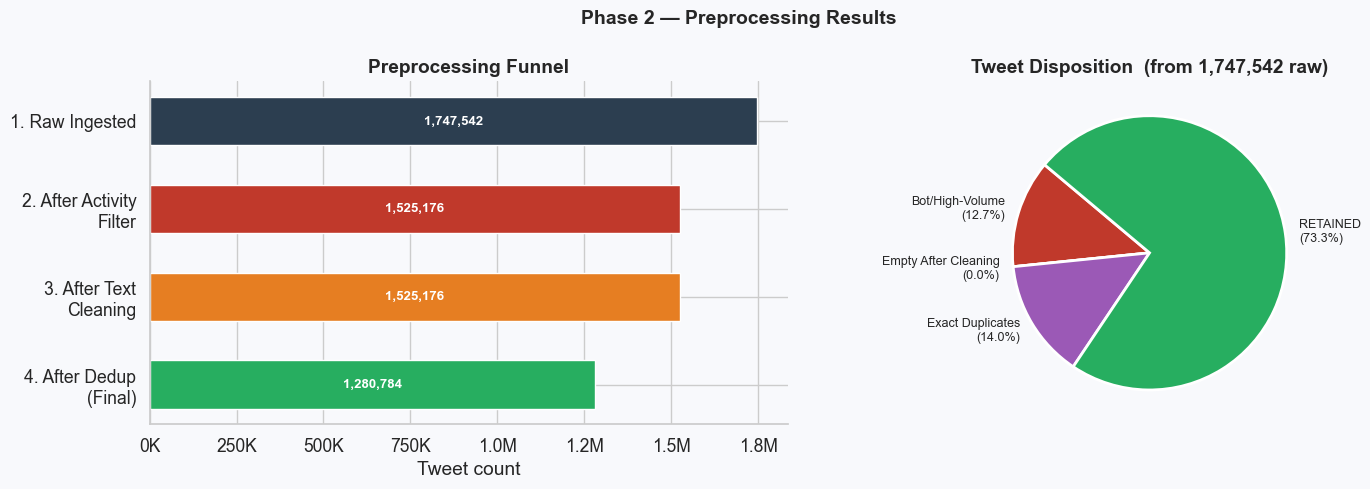

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Funnel bar chart ──────────────────────────────────────────────────────────
ax = axes[0]
stages = [
    ("1. Raw Ingested",        initial,                       "#2C3E50"),
    ("2. After Activity\nFilter", initial - rm_act,          TRUMP_COLOR),
    ("3. After Text\nCleaning",   initial - rm_act - rm_clean, "#E67E22"),
    ("4. After Dedup\n(Final)",   final,                     POS_COLOR),
]
names  = [s[0] for s in stages]
vals   = [s[1] for s in stages]
colors = [s[2] for s in stages]
bars   = ax.barh(names, vals, color=colors, height=0.55, edgecolor="white")
for bar, val in zip(bars, vals):
    ax.text(val * 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:,}", ha="center", va="center",
            color="white", fontweight="bold", fontsize=9.5)
ax.set_xlabel("Tweet count")
ax.set_title("Preprocessing Funnel", weight="bold")
ax.xaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
ax.invert_yaxis()

# ── Disposition pie ───────────────────────────────────────────────────────────
ax2 = axes[1]
pie_vals   = [rm_act, rm_clean, rm_dedup, final]
pie_labels = [
    f"Bot/High-Volume\n({rm_act/initial*100:.1f}%)",
    f"Empty After Cleaning\n({rm_clean/initial*100:.1f}%)",
    f"Exact Duplicates\n({rm_dedup/initial*100:.1f}%)",
    f"RETAINED\n({final/initial*100:.1f}%)",
]
pie_colors = [TRUMP_COLOR, "#E67E22", "#9B59B6", POS_COLOR]
ax2.pie(pie_vals, labels=pie_labels, colors=pie_colors, startangle=140,
        wedgeprops=dict(edgecolor="white", linewidth=2),
        textprops=dict(fontsize=9))
ax2.set_title(f"Tweet Disposition  (from {initial:,} raw)", weight="bold")

fig.suptitle("Phase 2 — Preprocessing Results", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(GRAPH_OUT / "phase2_preprocessing_funnel.png", dpi=150, bbox_inches="tight")
plt.show()


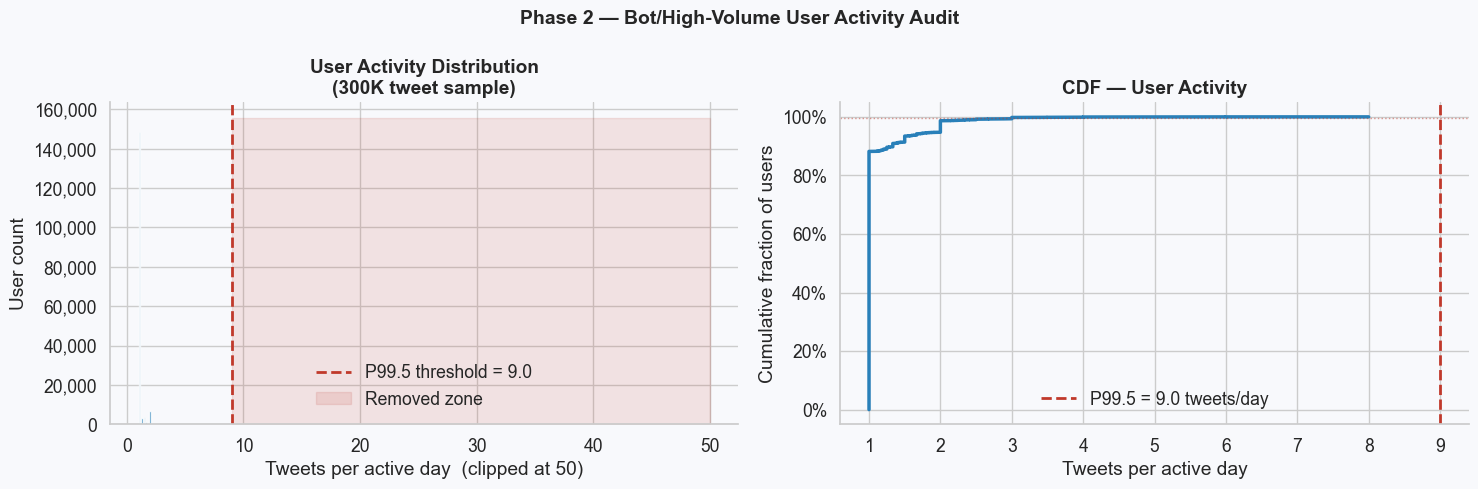

Users above threshold in sample: 0.00%


In [6]:
# ── User activity distribution (from Phase 2 v2 cleaned data sample) ─────────
df_clean = pd.read_parquet(
    ROOT / "data" / "02_interim" / "phase2_v2" / "twitter_cleaned_v2.parquet"
)
sample = df_clean.sample(n=min(300_000, len(df_clean)), random_state=42).copy()
sample["_day"] = pd.to_datetime(sample["created_at"], utc=True, errors="coerce").dt.floor("D")
sample_v = sample.dropna(subset=["_day"])

user_total  = sample_v.groupby("user_id").size().rename("total_tweets")
user_active = sample_v.groupby("user_id")["_day"].nunique().rename("active_days")
um = pd.concat([user_total, user_active], axis=1)
um["tweets_per_active_day"] = um["total_tweets"] / um["active_days"].replace(0, np.nan)
um = um.dropna(subset=["tweets_per_active_day"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Histogram ────────────────────────────────────────────────────────────────
ax = axes[0]
clipped = um["tweets_per_active_day"].clip(upper=50)
ax.hist(clipped, bins=60, color=BIDEN_COLOR, edgecolor="white", alpha=0.85)
ax.axvline(thresh, color=TRUMP_COLOR, lw=2, ls="--",
           label=f"P99.5 threshold = {thresh:.1f}")
ax.fill_betweenx([0, ax.get_ylim()[1] or 1], thresh, 50,
                 alpha=0.12, color=TRUMP_COLOR, label="Removed zone")
ax.set_xlabel("Tweets per active day  (clipped at 50)")
ax.set_ylabel("User count")
ax.set_title("User Activity Distribution\n(300K tweet sample)", weight="bold")
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── CDF ──────────────────────────────────────────────────────────────────────
ax2 = axes[1]
sv  = np.sort(clipped)
cdf = np.arange(1, len(sv)+1) / len(sv)
ax2.plot(sv, cdf, color=BIDEN_COLOR, lw=2.5)
ax2.axvline(thresh, color=TRUMP_COLOR, lw=2, ls="--",
            label=f"P99.5 = {thresh:.1f} tweets/day")
ax2.axhline(0.995, color=TRUMP_COLOR, lw=1, ls=":", alpha=0.5)
ax2.set_xlabel("Tweets per active day")
ax2.set_ylabel("Cumulative fraction of users")
ax2.set_title("CDF — User Activity", weight="bold")
ax2.legend(frameon=False)
ax2.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))

fig.suptitle("Phase 2 — Bot/High-Volume User Activity Audit", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(GRAPH_OUT / "phase2_activity_audit.png", dpi=150, bbox_inches="tight")
plt.show()
pct_removed = (um["tweets_per_active_day"] > thresh).mean() * 100
print(f"Users above threshold in sample: {pct_removed:.2f}%")


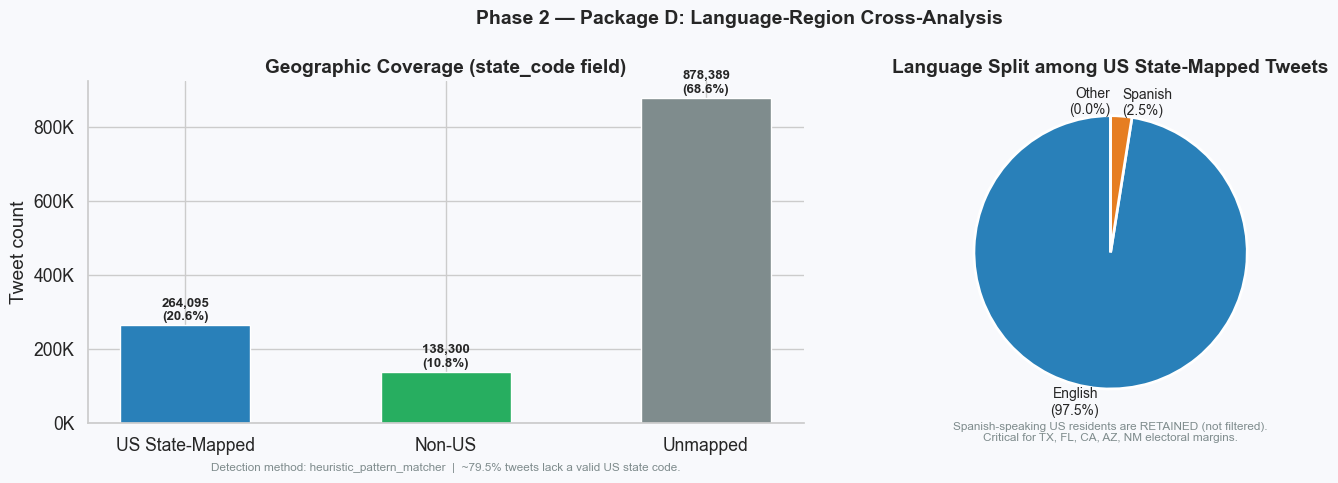

In [7]:
# ── Package D: Language-Region Coverage ──────────────────────────────────────
pkd = p2["package_d_language_region_summary"]
total_t  = pkd["total_tweets"]
us_state = pkd["us_state_tweets"]
us_es    = pkd["us_spanish_tweets"]
us_other = pkd["us_other_language_tweets"]
us_en    = us_state - us_es - us_other
non_us   = total_t - us_state - pkd["unmapped_tweets"]
unmapped = pkd["unmapped_tweets"]
method   = pkd.get("language_detection_method", "heuristic_pattern_matcher")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Region bar ────────────────────────────────────────────────────────────────
ax = axes[0]
rnames = ["US State-Mapped", "Non-US", "Unmapped"]
rvals  = [us_state, non_us, unmapped]
rcols  = [BIDEN_COLOR, POS_COLOR, NEUTRAL_COLOR]
bars   = ax.bar(rnames, rvals, color=rcols, edgecolor="white", width=0.5)
for bar, v in zip(bars, rvals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_t*0.005,
            f"{v:,}\n({v/total_t*100:.1f}%)",
            ha="center", va="bottom", fontsize=9.5, fontweight="bold")
ax.set_ylabel("Tweet count")
ax.set_title("Geographic Coverage (state_code field)", weight="bold")
ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.text(0.5, -0.14,
        f"Detection method: {method}  |  ~79.5% tweets lack a valid US state code.",
        ha="center", transform=ax.transAxes, fontsize=8.5, color=NEUTRAL_COLOR)

# ── US language pie ───────────────────────────────────────────────────────────
ax2 = axes[1]
if us_state > 0:
    wvals  = [max(us_en, 0), max(us_es, 0), max(us_other, 0)]
    wlabels= [
        f"English\n({us_en/us_state*100:.1f}%)",
        f"Spanish\n({us_es/us_state*100:.1f}%)",
        f"Other\n({us_other/us_state*100:.1f}%)",
    ]
    wcols  = [BIDEN_COLOR, "#E67E22", NEUTRAL_COLOR]
    ax2.pie(wvals, labels=wlabels, colors=wcols, startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2),
            textprops=dict(fontsize=10))
    ax2.set_title("Language Split among US State-Mapped Tweets", weight="bold")
    ax2.text(0, -1.38,
        "Spanish-speaking US residents are RETAINED (not filtered).\n"
        "Critical for TX, FL, CA, AZ, NM electoral margins.",
        ha="center", fontsize=8.5, color=NEUTRAL_COLOR)

fig.suptitle("Phase 2 — Package D: Language-Region Cross-Analysis", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(GRAPH_OUT / "phase2_language_region.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 💬 Phase 3 — Sentiment Scoring

Each tweet is scored with **VADER** (Valence Aware Dictionary and sEntiment Reasoner).

| Column | Description | Range |
|---|---|---|
| `vader_compound` | Aggregate normalised sentiment score | `[−1.0, +1.0]` |
| `vader_label` | Thresholded label | `negative` / `neutral` / `positive` |
| `sarcasm_risk_score` | Heuristic linguistic sarcasm signal | `[0.0, 1.0]` |

**VADER thresholds** (standard):
- `compound ≥ +0.05` → **positive**
- `compound ≤ −0.05` → **negative**
- otherwise → **neutral**

> **RoBERTa status**: `cardiffnlp/twitter-roberta-base-sentiment-latest` is the intended production  
> model but requires GPU inference — deferred. VADER is the authoritative baseline.  
> `roberta_score` column is stored as `NaN` with status `"deferred_requires_gpu"`.

> **Sarcasm note**: The `sarcasm_risk_score` is a heuristic proxy (ALL-CAPS ratio, sarcasm cue phrases,  
> punctuation patterns). A high score flags tweets for manual review but does **not** invert the label.


In [8]:
df = pd.read_parquet(
    ROOT / "data" / "02_interim" / "phase3_v2" / "twitter_sentiment_v2.parquet"
)
sample_df = df.sample(n=min(200_000, len(df)), random_state=42)

print(f"Total scored: {len(df):,}")
print("\nVADER label distribution:")
for lbl, cnt in df["vader_label"].value_counts().items():
    bar = "█" * int(cnt / len(df) * 40)
    print(f"  {lbl:10s}  {cnt:>9,}  {cnt/len(df)*100:5.1f}%  {bar}")
print(f"\nMean compound:      {df['vader_compound'].mean():.4f}")
print(f"Std compound:       {df['vader_compound'].std():.4f}")
print(f"Mean sarcasm risk:  {df['sarcasm_risk_score'].mean():.4f}")


Total scored: 1,280,784

VADER label distribution:
  neutral       488,163   38.1%  ███████████████
  positive      446,283   34.8%  █████████████
  negative      346,338   27.0%  ██████████

Mean compound:      0.0527
Std compound:       0.4702
Mean sarcasm risk:  0.0543


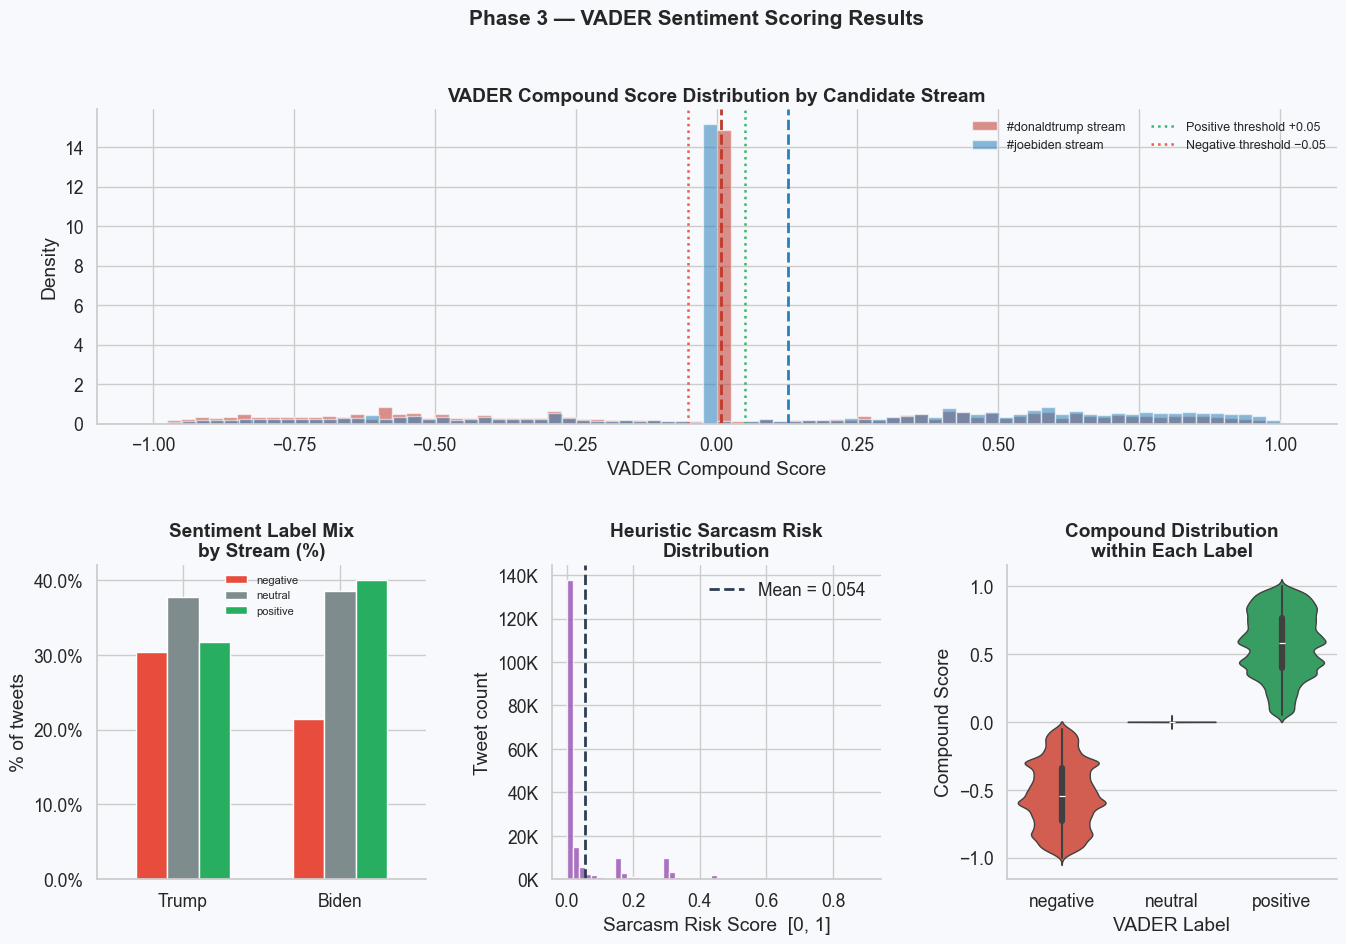

In [9]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── (1) Compound histogram by stream ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
t_samp = sample_df[sample_df["candidate"]=="donald_trump"]["vader_compound"]
b_samp = sample_df[sample_df["candidate"]=="joe_biden"]["vader_compound"]
ax1.hist(t_samp, bins=80, color=TRUMP_COLOR, alpha=0.55, density=True, label="#donaldtrump stream")
ax1.hist(b_samp, bins=80, color=BIDEN_COLOR, alpha=0.55, density=True, label="#joebiden stream")
ax1.axvline(0.05,  color=POS_COLOR, ls=":", lw=1.8, alpha=0.9, label="Positive threshold +0.05")
ax1.axvline(-0.05, color=NEG_COLOR, ls=":", lw=1.8, alpha=0.9, label="Negative threshold −0.05")
ax1.axvline(t_samp.mean(), color=TRUMP_COLOR, ls="--", lw=2)
ax1.axvline(b_samp.mean(), color=BIDEN_COLOR, ls="--", lw=2)
ax1.set_xlabel("VADER Compound Score")
ax1.set_ylabel("Density")
ax1.set_title("VADER Compound Score Distribution by Candidate Stream", weight="bold")
ax1.legend(frameon=False, ncol=2, fontsize=9)

# ── (2) Label % by candidate stream ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
lbc = (sample_df.groupby(["candidate","vader_label"]).size()
       .unstack(fill_value=0)
       .rename(index={"donald_trump":"Trump","joe_biden":"Biden"}))
lbc_pct = lbc.div(lbc.sum(axis=1), axis=0) * 100
pal = {"negative": NEG_COLOR, "neutral": NEUTRAL_COLOR, "positive": POS_COLOR}
lbc_pct.plot(kind="bar", ax=ax2, color=pal, edgecolor="white", width=0.6)
ax2.set_ylabel("% of tweets")
ax2.set_title("Sentiment Label Mix\nby Stream (%)", weight="bold")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=0)
ax2.legend(frameon=False, fontsize=8)
ax2.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter())

# ── (3) Sarcasm risk histogram ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(sample_df["sarcasm_risk_score"], bins=50,
         color="#9B59B6", edgecolor="white", alpha=0.85)
mn = sample_df["sarcasm_risk_score"].mean()
ax3.axvline(mn, color="#2C3E50", ls="--", lw=2, label=f"Mean = {mn:.3f}")
ax3.set_xlabel("Sarcasm Risk Score  [0, 1]")
ax3.set_ylabel("Tweet count")
ax3.set_title("Heuristic Sarcasm Risk\nDistribution", weight="bold")
ax3.legend(frameon=False)
ax3.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x/1e3)}K"))

# ── (4) Violin: compound by label ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
sns.violinplot(data=sample_df, x="vader_label", y="vader_compound",
               order=["negative","neutral","positive"],
               palette={"negative":NEG_COLOR,"neutral":NEUTRAL_COLOR,"positive":POS_COLOR},
               ax=ax4, linewidth=1)
ax4.set_xlabel("VADER Label")
ax4.set_ylabel("Compound Score")
ax4.set_title("Compound Distribution\nwithin Each Label", weight="bold")

fig.suptitle("Phase 3 — VADER Sentiment Scoring Results", fontsize=15, weight="bold")
plt.savefig(GRAPH_OUT / "phase3_sentiment_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 📊 Phase 4 — Temporal Aggregation  (H1 Setup)

Phase 4 reshapes tweet-level sentiment into time-series aggregates for **H1 ITSA**:

$$N_t = \text{tweet volume per hour}, \quad \mu_t = \bar{s}_t, \quad \sigma_t = \text{std}(s_t)$$

**$\sigma_t$ (polarization)** rises when sentiment is bimodal — e.g. some strongly pro-Biden, others  
strongly anti-Biden at the same hour — a sign of a divisive political event.


In [10]:
hourly = pd.read_parquet(ROOT / "data" / "03_processed" / "temporal_hourly_matrix.parquet")
daily  = pd.read_parquet(ROOT / "data" / "03_processed" / "temporal_daily_matrix.parquet")
events = pd.read_parquet(ROOT / "data" / "03_processed" / "temporal_event_windows.parquet")
spatial = pd.read_parquet(ROOT / "data" / "03_processed" / "spatial_state_matrix.parquet")

hourly["timestamp_hourly"] = pd.to_datetime(hourly["timestamp_hourly"], utc=True)
daily["timestamp_daily"]   = pd.to_datetime(daily["timestamp_daily"],  utc=True)

print(f"Hourly rows :  {len(hourly):,}  (one row per hour with data)")
print(f"Daily rows  :  {len(daily):,}  (one row per day)")
print(f"Event window:  {len(events):,}  rows  across {events['event_name'].nunique() if 'event_name' in events else 0} events")
print(f"Spatial rows:  {len(spatial):,}  (one row per US state + DC)")


Hourly rows :  599  (one row per hour with data)
Daily rows  :  25  (one row per day)
Event window:  345  rows  across 4 events
Spatial rows:  51  (one row per US state + DC)


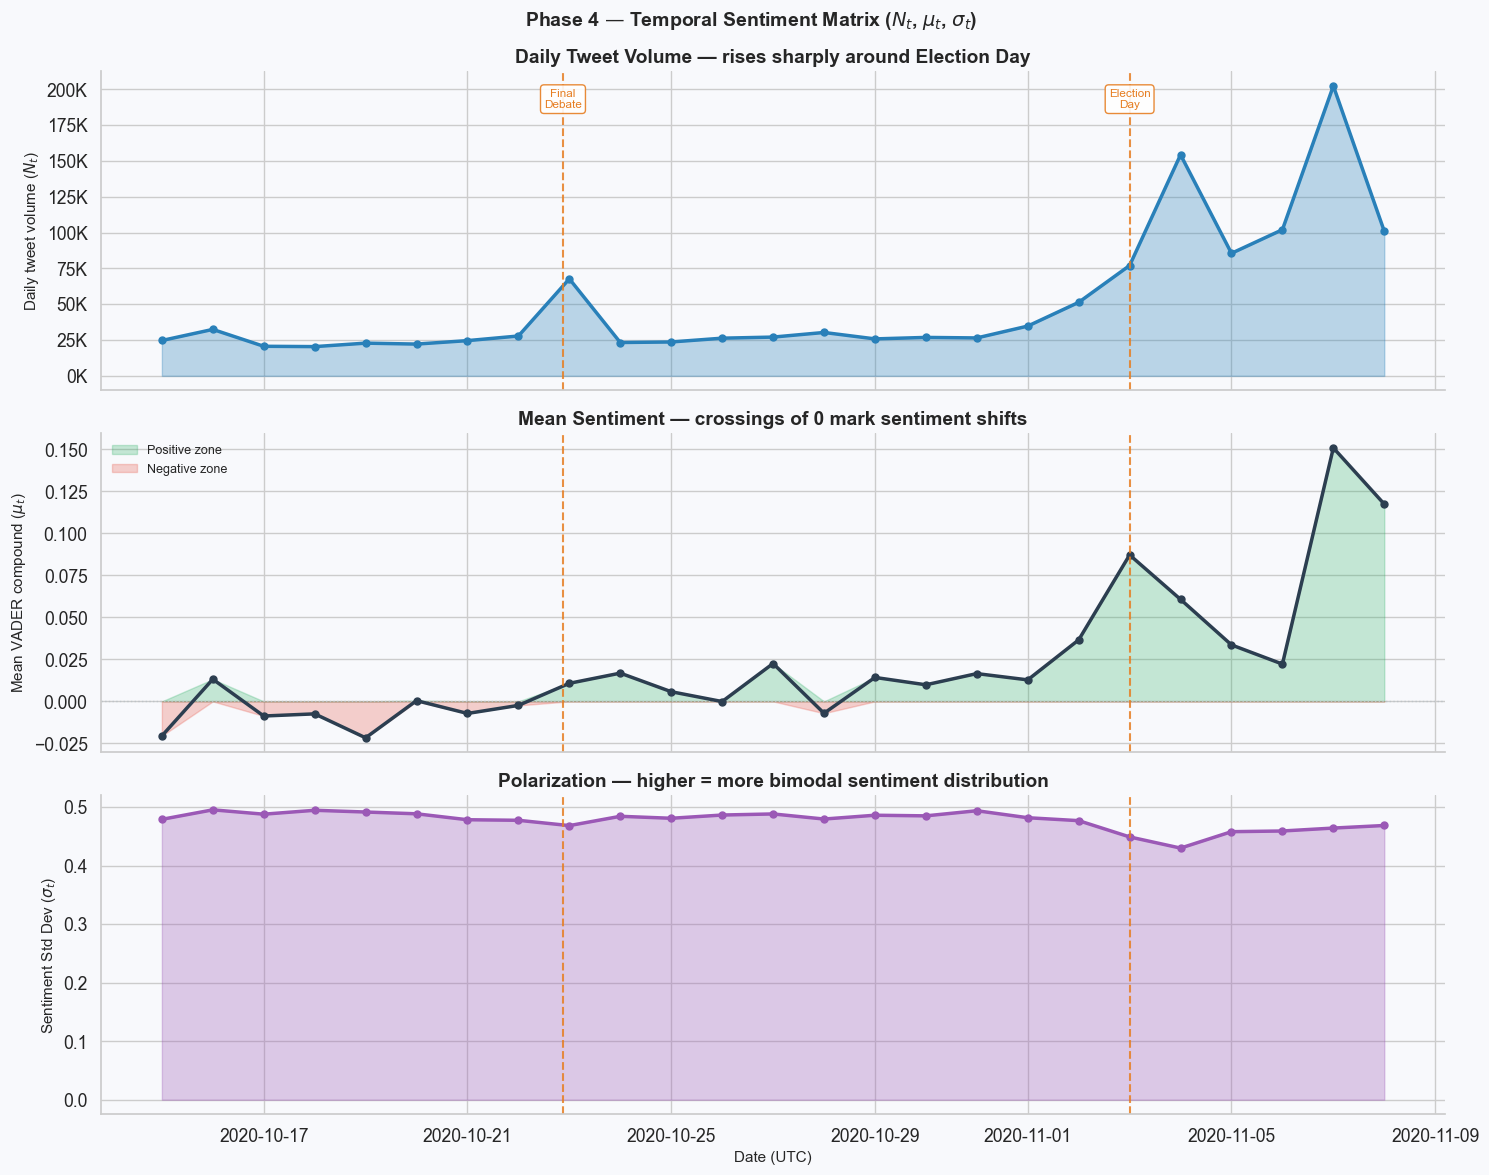

In [11]:
ann_events = [
    (pd.Timestamp("2020-10-22 21:00:00", tz="UTC"), "Final\nDebate"),
    (pd.Timestamp("2020-11-03 00:00:00", tz="UTC"), "Election\nDay"),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# ── Volume ────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(daily["timestamp_daily"], daily["volume"], alpha=0.3, color=BIDEN_COLOR)
ax.plot(daily["timestamp_daily"], daily["volume"],
        color=BIDEN_COLOR, lw=2.5, marker="o", ms=5)
ax.set_ylabel("Daily tweet volume ($N_t$)", fontsize=11)
ax.set_title("Daily Tweet Volume — rises sharply around Election Day", weight="bold")
ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# ── Mean sentiment ────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.axhline(0, color="#BDC3C7", lw=1, ls=":")
ax2.fill_between(daily["timestamp_daily"],
                 daily["mean_sentiment"].clip(lower=0), 0,
                 alpha=0.25, color=POS_COLOR, label="Positive zone")
ax2.fill_between(daily["timestamp_daily"],
                 daily["mean_sentiment"].clip(upper=0), 0,
                 alpha=0.25, color=NEG_COLOR, label="Negative zone")
ax2.plot(daily["timestamp_daily"], daily["mean_sentiment"],
         color="#2C3E50", lw=2.5, marker="o", ms=5)
ax2.set_ylabel("Mean VADER compound ($\mu_t$)", fontsize=11)
ax2.set_title("Mean Sentiment — crossings of 0 mark sentiment shifts", weight="bold")
ax2.legend(frameon=False, fontsize=9)

# ── Polarization ──────────────────────────────────────────────────────────────
ax3 = axes[2]
ax3.fill_between(daily["timestamp_daily"], daily["std_sentiment"],
                 alpha=0.3, color="#9B59B6")
ax3.plot(daily["timestamp_daily"], daily["std_sentiment"],
         color="#9B59B6", lw=2.5, marker="o", ms=5)
ax3.set_ylabel("Sentiment Std Dev ($\sigma_t$)", fontsize=11)
ax3.set_title("Polarization — higher = more bimodal sentiment distribution", weight="bold")
ax3.set_xlabel("Date (UTC)", fontsize=11)

for dt, lbl in ann_events:
    for a in axes:
        a.axvline(dt, color="#E67E22", lw=1.5, ls="--", alpha=0.85)
    axes[0].text(dt, axes[0].get_ylim()[1]*0.88, lbl, ha="center",
                 fontsize=8.5, color="#E67E22",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#E67E22", alpha=0.9))

fig.suptitle("Phase 4 — Temporal Sentiment Matrix ($N_t$, $\mu_t$, $\sigma_t$)",
             fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(GRAPH_OUT / "phase4_temporal_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


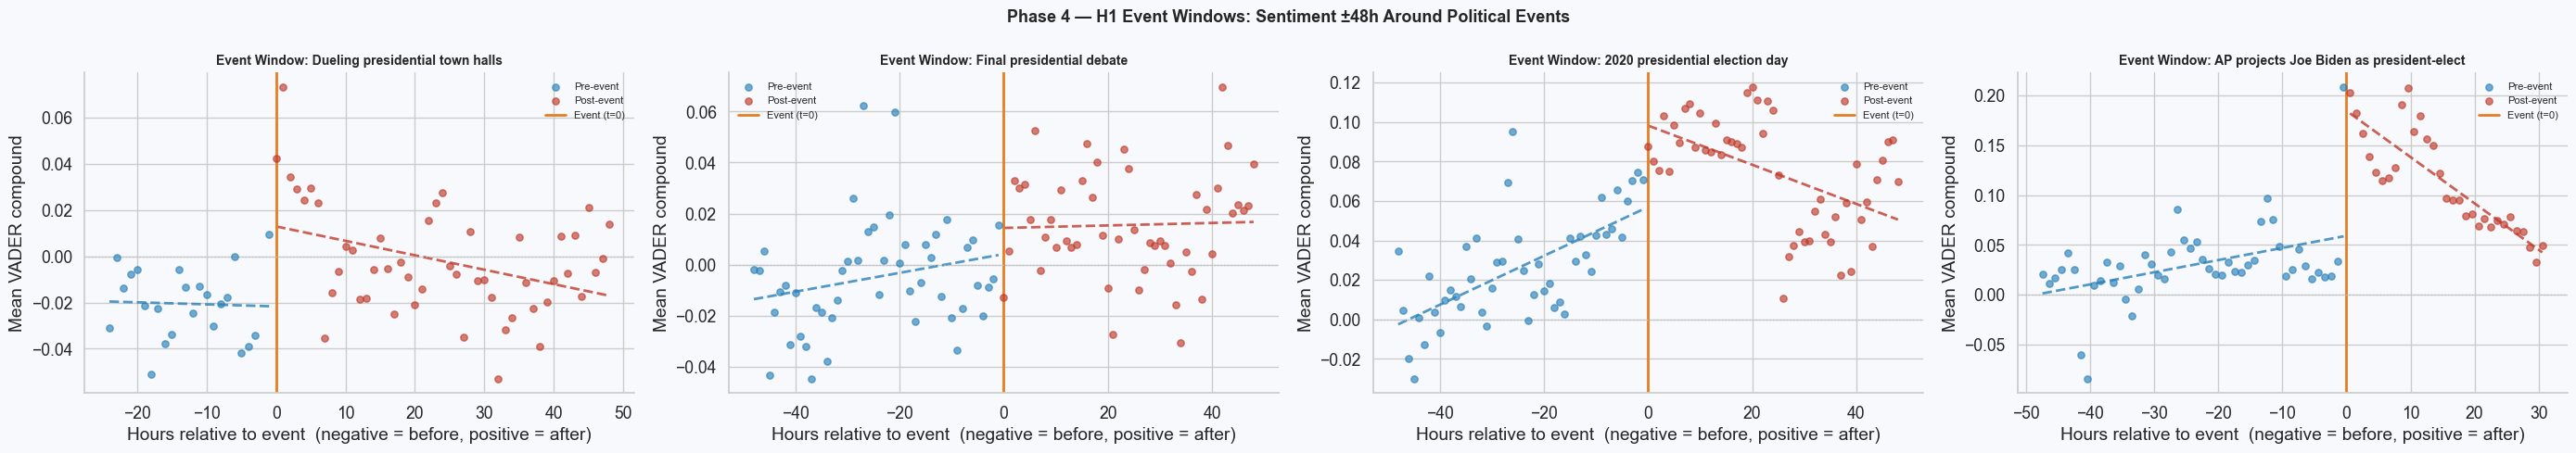

In [12]:
# ── Event window shock plots (H1 visual setup) ────────────────────────────────
if len(events) > 0 and "event_name" in events.columns:
    evt_names = events["event_name"].unique()
    n = len(evt_names)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 5), squeeze=False)

    for idx, evt in enumerate(evt_names):
        ax = axes[0][idx]
        grp  = events[events["event_name"]==evt].sort_values("time_elapsed_hours")
        pre  = grp[grp["post_event_dummy"]==0]
        post = grp[grp["post_event_dummy"]==1]

        ax.scatter(pre["time_elapsed_hours"],  pre["mean_sentiment"],
                   s=28, color=BIDEN_COLOR, alpha=0.65, label="Pre-event", zorder=3)
        ax.scatter(post["time_elapsed_hours"], post["mean_sentiment"],
                   s=28, color=TRUMP_COLOR, alpha=0.65, label="Post-event", zorder=3)

        for g, col in [(pre, BIDEN_COLOR), (post, TRUMP_COLOR)]:
            if len(g) >= 3:
                z = np.polyfit(g["time_elapsed_hours"], g["mean_sentiment"], 1)
                xr = np.linspace(g["time_elapsed_hours"].min(), g["time_elapsed_hours"].max(), 100)
                ax.plot(xr, np.poly1d(z)(xr), color=col, lw=2, ls="--", alpha=0.8)

        ax.axvline(0, color="#E67E22", lw=2, label="Event (t=0)")
        ax.axhline(0, color="#BDC3C7", lw=1, ls=":")
        ax.set_xlabel("Hours relative to event  (negative = before, positive = after)")
        ax.set_ylabel("Mean VADER compound")
        ax.set_title(f"Event Window: {evt}", weight="bold", fontsize=10)
        ax.legend(frameon=False, fontsize=8)

    fig.suptitle("Phase 4 — H1 Event Windows: Sentiment ±48h Around Political Events",
                 fontsize=13, weight="bold")
    plt.tight_layout()
    plt.savefig(GRAPH_OUT / "phase4_event_windows.png", dpi=150, bbox_inches="tight")
    plt.show()


---
## 🗺️ Phase 4 — Spatial Aggregation  (H2 Setup)

The **state-level sentiment margin** $X_i$ is:

$$X_i = \bar{s}^{\text{Biden}}_i - \bar{s}^{\text{Trump}}_i$$

where $\bar{s}$ is the mean VADER compound score for tweets in that state's respective candidate stream.

**Interpretation**:
- $X_i > 0$ → Biden-related tweets more positive (or Trump-related more negative) in state $i$
- $X_i < 0$ → Trump-related tweets more positive in state $i$

This is regressed against $Y_i$ = **certified 2020 vote margin** (Biden% − Trump%).

> **Limitation**: Only ~20.5% of tweets carry a valid `state_code`. The spatial matrix is built from  
> this geocoded subset, which may not be representative — selection bias should be acknowledged.


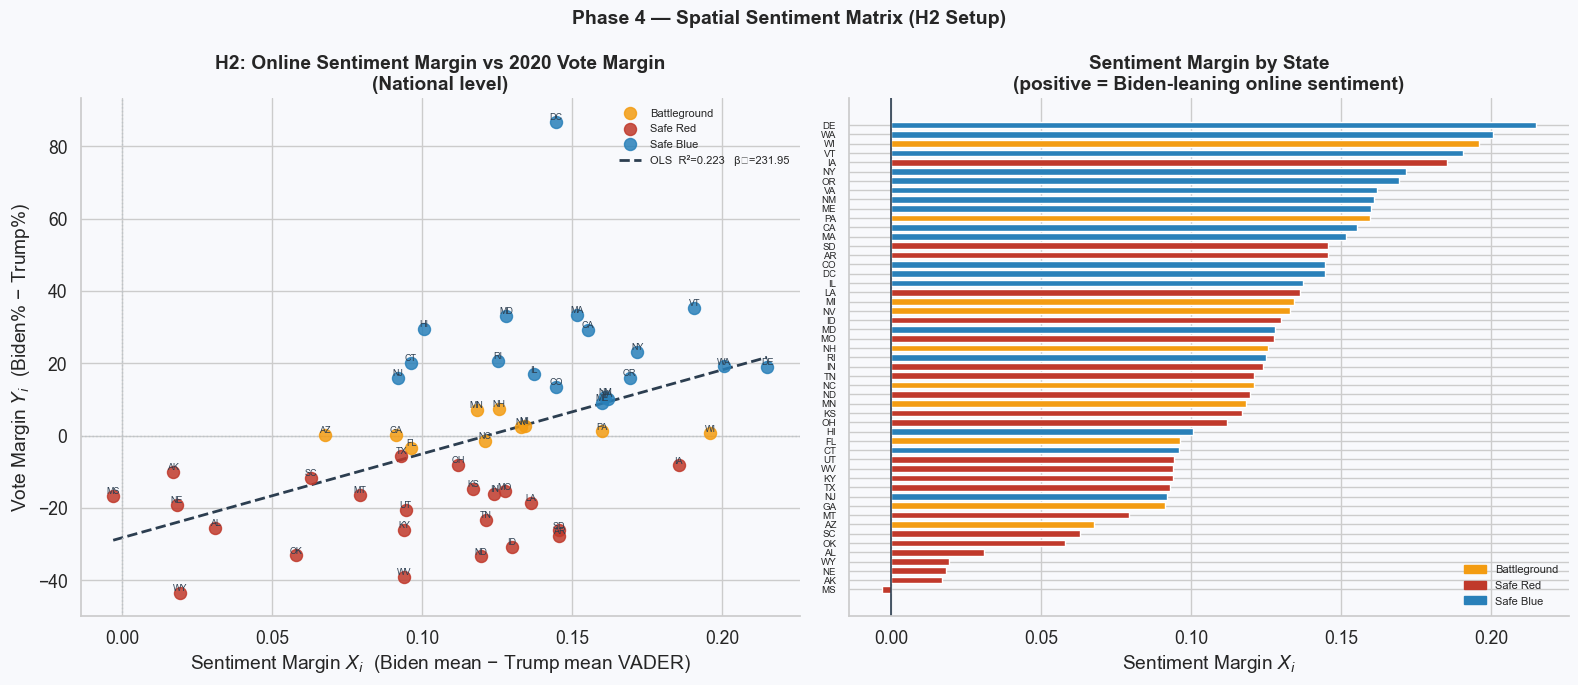

State coverage note:
  Tweets with valid US state code: 264,095 / 1,280,784  (20.6%)
  Spatial matrix built from this geocoded subset only.


In [13]:
cmap  = {"battleground": BG_COLOR, "safe_red": TRUMP_COLOR, "safe_blue": BIDEN_COLOR}
cs    = spatial["historical_classification"].map(cmap).fillna(NEUTRAL_COLOR)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Scatter Xi vs Yi ──────────────────────────────────────────────────────────
ax = axes[0]
for cls, col, lbl in [("battleground",BG_COLOR,"Battleground"),
                       ("safe_red",TRUMP_COLOR,"Safe Red"),
                       ("safe_blue",BIDEN_COLOR,"Safe Blue")]:
    sub = spatial[spatial["historical_classification"]==cls]
    ax.scatter(sub["state_sentiment_margin_Xi"],
               sub["democratic_margin_pct_2020"],
               color=col, s=75, alpha=0.85, label=lbl, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row["state_code"],
                    (row["state_sentiment_margin_Xi"], row["democratic_margin_pct_2020"]),
                    fontsize=6.5, ha="center", va="bottom", color="#2C3E50")

# OLS fit
Xm = sm.add_constant(spatial["state_sentiment_margin_Xi"].fillna(0))
ym = spatial["democratic_margin_pct_2020"].fillna(0)
fit = sm.OLS(ym, Xm).fit()
xr  = np.linspace(spatial["state_sentiment_margin_Xi"].min(),
                   spatial["state_sentiment_margin_Xi"].max(), 200)
ax.plot(xr, fit.params[0] + fit.params[1]*xr, color="#2C3E50", lw=2, ls="--",
        label=f"OLS  R²={fit.rsquared:.3f}   β₁={fit.params[1]:.2f}")
ax.axhline(0, color="#BDC3C7", lw=1, ls=":")
ax.axvline(0, color="#BDC3C7", lw=1, ls=":")
ax.set_xlabel("Sentiment Margin $X_i$  (Biden mean − Trump mean VADER)")
ax.set_ylabel("Vote Margin $Y_i$  (Biden% − Trump%)")
ax.set_title("H2: Online Sentiment Margin vs 2020 Vote Margin\n(National level)", weight="bold")
ax.legend(frameon=False, fontsize=8)

# ── Bar: Xi by state sorted ────────────────────────────────────────────────────
ax2 = axes[1]
srt  = spatial.sort_values("state_sentiment_margin_Xi")
bcols = srt["historical_classification"].map(cmap).fillna(NEUTRAL_COLOR)
ax2.barh(srt["state_code"], srt["state_sentiment_margin_Xi"],
         color=bcols.values, edgecolor="white", height=0.72)
ax2.axvline(0, color="#2C3E50", lw=1.2)
ax2.set_xlabel("Sentiment Margin $X_i$")
ax2.set_title("Sentiment Margin by State\n(positive = Biden-leaning online sentiment)", weight="bold")
ax2.tick_params(axis="y", labelsize=7)
legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in [(BG_COLOR,"Battleground"),(TRUMP_COLOR,"Safe Red"),(BIDEN_COLOR,"Safe Blue")]]
ax2.legend(handles=legend_patches, frameon=False, fontsize=8, loc="lower right")

fig.suptitle("Phase 4 — Spatial Sentiment Matrix (H2 Setup)", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(GRAPH_OUT / "phase4_spatial_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("State coverage note:")
us_codes = {"AK","AL","AR","AZ","CA","CO","CT","DC","DE","FL","GA","HI","IA","ID","IL","IN",
            "KS","KY","LA","MA","MD","ME","MI","MN","MO","MS","MT","NC","ND","NE","NH","NJ",
            "NM","NV","NY","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VA","VT","WA","WI","WV","WY"}
df_full = pd.read_parquet(ROOT / "data" / "02_interim" / "phase3_v2" / "twitter_sentiment_v2.parquet")
n_us = df_full["state_code"].astype(str).str.strip().isin(us_codes).sum()
print(f"  Tweets with valid US state code: {n_us:,} / {len(df_full):,}  ({n_us/len(df_full)*100:.1f}%)")
print(f"  Spatial matrix built from this geocoded subset only.")


---
## 📐 Phase 5 — Statistical Hypothesis Testing

### Hypothesis 1 — Interrupted Time Series Analysis (ITSA)

$$Y_t = \beta_0 + \beta_1 T_t + \beta_2 D_t + \beta_3 (T_t \cdot D_t) + \varepsilon_t$$

| Coefficient | Meaning | Significant if |
|---|---|---|
| $\beta_0$ | Baseline sentiment level | — |
| $\beta_1$ | Pre-event time trend (slope) | — |
| $\beta_2$ | **Immediate shock** at event | $p < 0.05$ |
| $\beta_3$ | **Post-event slope change** (decay/amplification) | $p < 0.05$ |

HC1 heteroscedasticity-robust standard errors used.

### Hypothesis 2 — Spatial OLS Regression

$$Y_i = \beta_0 + \beta_1 X_i + \sum_k \gamma_k Z_{ki} + \varepsilon_i$$

- $X_i$ = online sentiment margin (Phase 4)
- $Y_i$ = certified 2020 vote margin
- $Z_{ki}$ = demographic controls: median age, income, urbanization, education, Hispanic%

Stratified into: **National** · **Battleground** · **Safe States**


In [14]:
from src.phase5_modeling.itsa_ols_evaluator import ITSAOLSEvaluator

evaluator = ITSAOLSEvaluator()

# ── H1: ITSA per event ────────────────────────────────────────────────────────
h1_results = []
if len(events) > 0 and "event_name" in events.columns:
    for evt_name, grp in events.groupby("event_name"):
        if len(grp) >= 10:
            res = evaluator.evaluate_h1_itsa(grp, str(evt_name))
            h1_results.append(res)

# ── H2: OLS subgroups ─────────────────────────────────────────────────────────
h2_nat  = evaluator.evaluate_h2_ols(spatial, "National")
bg_df   = spatial[spatial["historical_classification"]=="battleground"]
safe_df = spatial[spatial["historical_classification"].isin(["safe_red","safe_blue"])]
h2_bg   = evaluator.evaluate_h2_ols(bg_df,   "Battleground") if len(bg_df)   >= 5 else None
h2_safe = evaluator.evaluate_h2_ols(safe_df, "Safe States")  if len(safe_df) >= 5 else None

print("─── H1 ITSA Results ───")
for res in h1_results:
    sig_b2 = "★" if res.p_value_immediate_shock < 0.05 else " "
    sig_b3 = "★" if res.p_value_post_slope_change < 0.05 else " "
    print(f"\n  Event: {res.event_name}")
    print(f"    β₂ shock:       {res.beta_2_immediate_shock:+.4f}  p={res.p_value_immediate_shock:.4f} {sig_b2}")
    print(f"    β₃ slope chg:   {res.beta_3_post_slope_change:+.6f}  p={res.p_value_post_slope_change:.4f} {sig_b3}")
    print(f"    R²:             {res.r_squared:.4f}")

print("\n─── H2 OLS Results ───")
for name, res in [("National",h2_nat),("Battleground",h2_bg),("Safe States",h2_safe)]:
    if res:
        sig = "★ SIGNIFICANT" if res.p_value_sentiment_margin < 0.05 else "  not significant"
        print(f"  {name:15s}  β₁={res.beta_1_sentiment_margin:+.4f}  p={res.p_value_sentiment_margin:.4f}  R²={res.r_squared:.4f}  N={res.sample_size}  {sig}")


─── H1 ITSA Results ───

  Event: 2020 presidential election day
    β₂ shock:       +0.0412  p=0.0000 ★
    β₃ slope chg:   -0.002232  p=0.0000 ★
    R²:             0.6298

  Event: AP projects Joe Biden as president-elect
    β₂ shock:       +0.1255  p=0.0000 ★
    β₃ slope chg:   -0.005872  p=0.0000 ★
    R²:             0.7065

  Event: Dueling presidential town halls
    β₂ shock:       +0.0346  p=0.0028 ★
    β₃ slope chg:   -0.000536  p=0.3966  
    R²:             0.2471

  Event: Final presidential debate
    β₂ shock:       +0.0102  p=0.1658  
    β₃ slope chg:   -0.000319  p=0.2368  
    R²:             0.2150

─── H2 OLS Results ───
  National         β₁=+83.0380  p=0.0525  R²=0.8129  N=51    not significant
  Battleground     β₁=-46.7254  p=0.0033  R²=0.9735  N=10  ★ SIGNIFICANT
  Safe States      β₁=+66.1420  p=0.1816  R²=0.8380  N=41    not significant


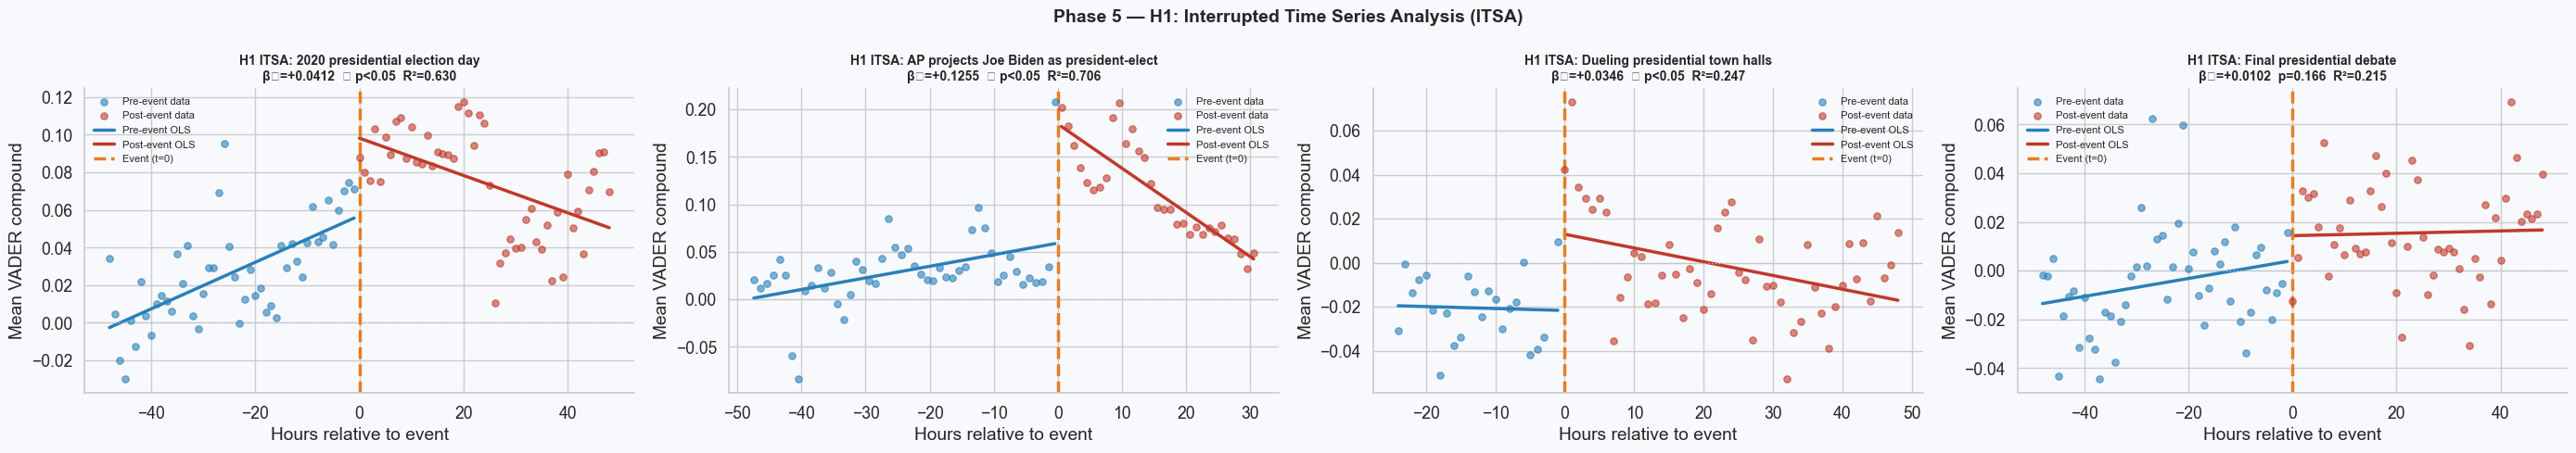

In [15]:
# ── H1 ITSA Fitted Line Plots ─────────────────────────────────────────────────
if h1_results:
    n_evts = len(h1_results)
    fig, axes = plt.subplots(1, n_evts, figsize=(7*n_evts, 5), squeeze=False)

    for idx, res in enumerate(h1_results):
        ax = axes[0][idx]
        grp  = events[events["event_name"]==res.event_name].sort_values("time_elapsed_hours")
        pre  = grp[grp["post_event_dummy"]==0]
        post = grp[grp["post_event_dummy"]==1]

        ax.scatter(pre["time_elapsed_hours"],  pre["mean_sentiment"],
                   s=28, color=BIDEN_COLOR, alpha=0.6, zorder=3, label="Pre-event data")
        ax.scatter(post["time_elapsed_hours"], post["mean_sentiment"],
                   s=28, color=TRUMP_COLOR, alpha=0.6, zorder=3, label="Post-event data")

        # Draw ITSA fitted segments
        if len(pre) > 0:
            t = pre["time_elapsed_hours"].values
            yhat = res.beta_0_baseline + res.beta_1_pre_slope * t
            ax.plot(t, yhat, color=BIDEN_COLOR, lw=2.5, label="Pre-event OLS")
        if len(post) > 0:
            t = post["time_elapsed_hours"].values
            yhat = (res.beta_0_baseline + res.beta_2_immediate_shock
                    + (res.beta_1_pre_slope + res.beta_3_post_slope_change) * t)
            ax.plot(t, yhat, color=TRUMP_COLOR, lw=2.5, label="Post-event OLS")

        ax.axvline(0, color="#E67E22", lw=2.5, ls="--", label="Event (t=0)")
        ax.axhline(0, color="#BDC3C7", lw=1, ls=":")
        sig_str = ("★ p<0.05" if res.p_value_immediate_shock < 0.05
                   else f"p={res.p_value_immediate_shock:.3f}")
        ax.set_title(f"H1 ITSA: {res.event_name}\nβ₂={res.beta_2_immediate_shock:+.4f}  {sig_str}  R²={res.r_squared:.3f}",
                     weight="bold", fontsize=10)
        ax.set_xlabel("Hours relative to event")
        ax.set_ylabel("Mean VADER compound")
        ax.legend(frameon=False, fontsize=8)

    fig.suptitle("Phase 5 — H1: Interrupted Time Series Analysis (ITSA)", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.savefig(GRAPH_OUT / "phase5_h1_itsa.png", dpi=150, bbox_inches="tight")
    plt.show()


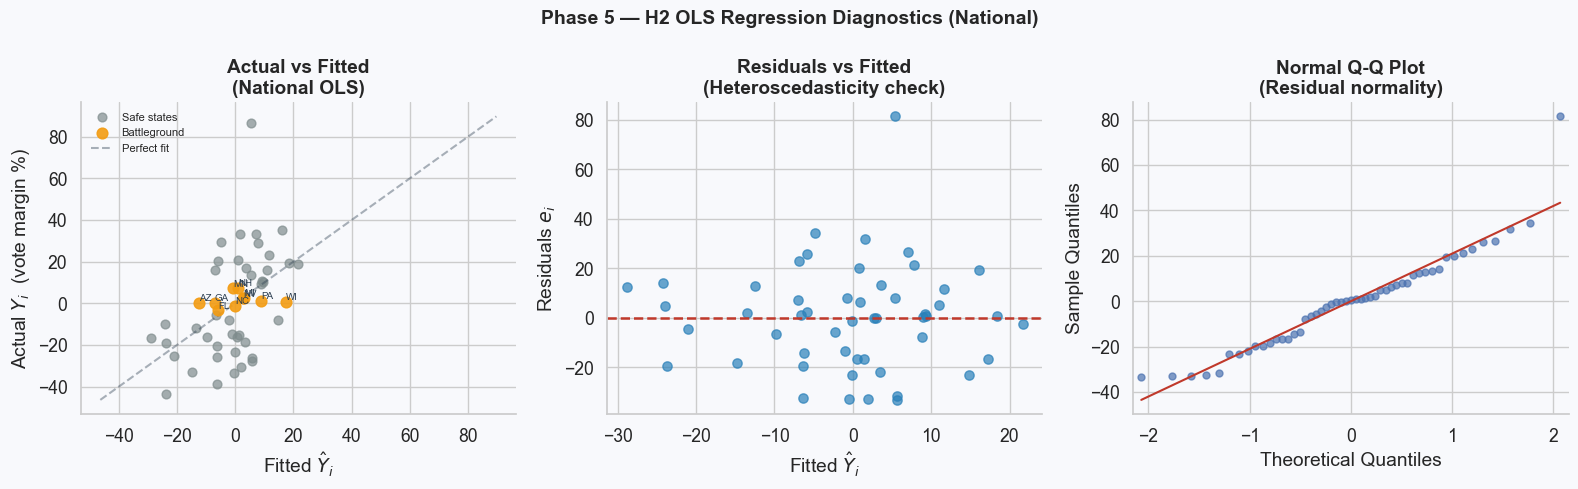

National OLS:  R²=0.2235   Adj R²=0.2076   N=51


In [16]:
# ── H2 OLS Residual Diagnostics ───────────────────────────────────────────────
Xm   = sm.add_constant(spatial["state_sentiment_margin_Xi"].fillna(0))
ym   = spatial["democratic_margin_pct_2020"].fillna(0)
mdl  = sm.OLS(ym, Xm).fit(cov_type="HC1")
fv   = mdl.fittedvalues
res  = mdl.resid
bg   = spatial["historical_classification"]=="battleground"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Actual vs Fitted ──────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(fv[~bg], ym[~bg], color=NEUTRAL_COLOR, s=40, alpha=0.7, label="Safe states")
ax.scatter(fv[bg],  ym[bg],  color=BG_COLOR,      s=60, alpha=0.9, label="Battleground", zorder=3)
for _, row in spatial[bg].iterrows():
    i = spatial.index.get_loc(_)
    ax.annotate(row["state_code"], (fv.iloc[i], ym.iloc[i]),
                fontsize=7, ha="left", va="bottom", color="#2C3E50")
lo = min(fv.min(), ym.min()) - 3
hi = max(fv.max(), ym.max()) + 3
ax.plot([lo,hi],[lo,hi], color="#2C3E50", lw=1.5, ls="--", alpha=0.4, label="Perfect fit")
ax.set_xlabel("Fitted $\hat{Y}_i$")
ax.set_ylabel("Actual $Y_i$  (vote margin %)")
ax.set_title("Actual vs Fitted\n(National OLS)", weight="bold")
ax.legend(frameon=False, fontsize=8)

# ── Residuals vs Fitted ────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.scatter(fv, res, color=BIDEN_COLOR, s=45, alpha=0.7)
ax2.axhline(0, color=TRUMP_COLOR, lw=1.8, ls="--")
ax2.set_xlabel("Fitted $\hat{Y}_i$")
ax2.set_ylabel("Residuals $e_i$")
ax2.set_title("Residuals vs Fitted\n(Heteroscedasticity check)", weight="bold")

# ── QQ Plot ───────────────────────────────────────────────────────────────────
ax3 = axes[2]
sm.qqplot(res, line="s", ax=ax3, alpha=0.7)
ax3.get_lines()[0].set(color=BIDEN_COLOR, markersize=5)
ax3.get_lines()[1].set(color=TRUMP_COLOR, lw=1.5)
ax3.set_title("Normal Q-Q Plot\n(Residual normality)", weight="bold")

fig.suptitle("Phase 5 — H2 OLS Regression Diagnostics (National)", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(GRAPH_OUT / "phase5_h2_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"National OLS:  R²={mdl.rsquared:.4f}   Adj R²={mdl.rsquared_adj:.4f}   N={int(mdl.nobs)}")


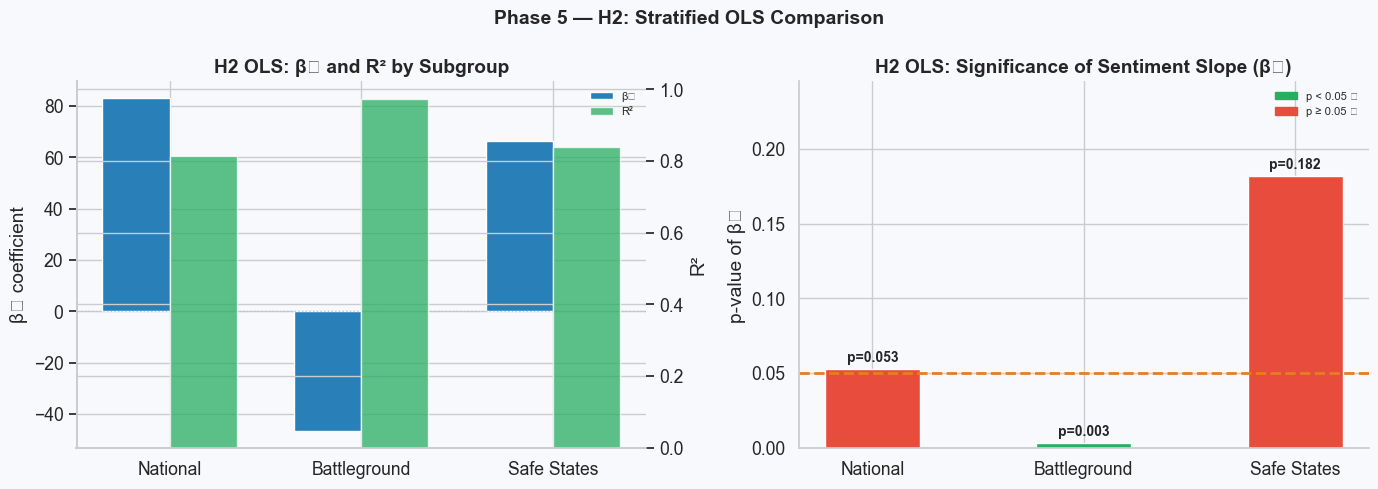

In [17]:
# ── H2 Stratified Comparison ──────────────────────────────────────────────────
rows = [(h2_nat,"National"), (h2_bg,"Battleground"), (h2_safe,"Safe States")]
rows = [(r,n) for r,n in rows if r is not None]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── β₁ and R² grouped bar ─────────────────────────────────────────────────────
ax = axes[0]
names = [n for _,n in rows]
b1s   = [r.beta_1_sentiment_margin for r,_ in rows]
r2s   = [r.r_squared for r,_ in rows]
x = np.arange(len(names))
w = 0.35
ax.bar(x - w/2, b1s, w, label="β₁ (sentiment slope)", color=BIDEN_COLOR, edgecolor="white")
ax2b = ax.twinx()
ax2b.bar(x + w/2, r2s, w, label="R²", color=POS_COLOR, alpha=0.75, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("β₁ coefficient"); ax2b.set_ylabel("R²")
ax.axhline(0, color="#BDC3C7", lw=1, ls=":")
ax.set_title("H2 OLS: β₁ and R² by Subgroup", weight="bold")
l1,_ = ax.get_legend_handles_labels()
l2,_ = ax2b.get_legend_handles_labels()
ax.legend(l1+l2, ["β₁","R²"], frameon=False, fontsize=8)

# ── p-value bar ───────────────────────────────────────────────────────────────
ax3 = axes[1]
pvs   = [r.p_value_sentiment_margin for r,_ in rows]
bcols = [POS_COLOR if p < 0.05 else NEG_COLOR for p in pvs]
bars  = ax3.bar(names, pvs, color=bcols, edgecolor="white", width=0.45)
ax3.axhline(0.05, color="#E67E22", lw=2, ls="--", label="α = 0.05")
for bar, p in zip(bars, pvs):
    ax3.text(bar.get_x() + bar.get_width()/2, p + 0.003,
             f"p={p:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax3.set_ylabel("p-value of β₁")
ax3.set_title("H2 OLS: Significance of Sentiment Slope (β₁)", weight="bold")
ax3.set_ylim(0, max(pvs)*1.35)
gp = mpatches.Patch(color=POS_COLOR, label="p < 0.05 ✅")
rp = mpatches.Patch(color=NEG_COLOR, label="p ≥ 0.05 ❌")
ax3.legend(handles=[gp, rp], frameon=False, fontsize=8)

fig.suptitle("Phase 5 — H2: Stratified OLS Comparison", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(GRAPH_OUT / "phase5_h2_stratified.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 📋 Pipeline Summary & Known Limitations

| Phase | Input | Output | Key Metric |
|---|---|---|---|
| **Phase 1** | Raw Kaggle CSVs | Phase 1 v2 Parquets | ~1.68M raw records |
| **Phase 2** | Phase 1 Parquets | Cleaned Parquet | 1,280,784 retained (~76%) |
| **Phase 3** | Cleaned Parquet | Sentiment Parquet | VADER scored; sarcasm heuristic |
| **Phase 4** | Sentiment Parquet | Temporal + Spatial matrices | 599 hourly rows; 51 state rows |
| **Phase 5** | Temporal + Spatial | H1 & H2 regression outputs | See R² / p-values above |

### Known Limitations

| # | Limitation | Impact | Mitigation |
|---|---|---|---|
| 1 | **RoBERTa deferred** — VADER is authoritative | May underestimate sarcasm/irony effects | Run GPU inference when available |
| 2 | **~79.5% unmapped state codes** | H2 spatial results use biased geocoded subset | Acknowledge selection bias in interpretation |
| 3 | **Spanish detection via heuristic regex** | Some Spanish tweets may be misclassified | Validated language classifier (e.g. fasttext) in future |
| 4 | **Candidate stream ≠ stance** | X_i not purely sentiment — conflates stream membership | Future: NLP-based candidate mention extraction |
| 5 | **ITSA power** — 25 days, hourly data | Short pre-event window limits statistical power | Extend window to full campaign season |


In [18]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("═══════════ Pipeline End-to-End Summary ═══════════")
summary = [
    ("Phase 1", "Raw ingestion",      f"{trump_n+biden_n:,}",  f"{trump_n+biden_n:,}",  "2 streams, window 2020-10-15→11-08"),
    ("Phase 2", "Preprocessing",      f"{initial:,}",           f"{final:,}",             f"Retention {final/initial*100:.1f}%"),
    ("Phase 3", "Sentiment scoring",  f"{final:,}",             f"{final:,}",             "VADER; sarcasm heuristic"),
    ("Phase 4", "Aggregation",        f"{final:,} tweets",      f"{len(spatial)} states", f"{len(hourly)} hourly slices"),
    ("Phase 5", "Statistical models", f"{len(spatial)} states", f"{len(rows)} subgroups", f"H2 National R²={h2_nat.r_squared:.3f}"),
]
print(f"{'Phase':<10} {'Stage':<22} {'In':<18} {'Out':<18} {'Notes'}")
print("─"*90)
for row in summary:
    print(f"{row[0]:<10} {row[1]:<22} {row[2]:<18} {row[3]:<18} {row[4]}")
print(f"\nAll graphs saved to: {GRAPH_OUT}")


═══════════ Pipeline End-to-End Summary ═══════════
Phase      Stage                  In                 Out                Notes
──────────────────────────────────────────────────────────────────────────────────────────
Phase 1    Raw ingestion          1,747,542          1,747,542          2 streams, window 2020-10-15→11-08
Phase 2    Preprocessing          1,747,542          1,280,784          Retention 73.3%
Phase 3    Sentiment scoring      1,280,784          1,280,784          VADER; sarcasm heuristic
Phase 4    Aggregation            1,280,784 tweets   51 states          599 hourly slices
Phase 5    Statistical models     51 states          3 subgroups        H2 National R²=0.813

All graphs saved to: D:\GW_UNIVERSITY\AIS\Social_Listener\Env\Social_Listener_V1\UOG_AIS_SOCIAL_LISTENER\output\graphs\overview_notebook
